# SPY Returns — Exploratory Data Analysis
**Dataset:** `spy_train_2019-01-01_2024-12-31.csv`  
**Period:** January 2019 – December 2024  


---

## Preface: Log Returns vs Simple Returns

Throughout this notebook we work with **log (continuously compounded) returns**:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

rather than simple (arithmetic) returns $R_t = (P_t - P_{t-1}) / P_{t-1}$.

**Reasons for this choice at the graduate level:**

| Property | Log Return | Simple Return |
|---|---|---|
| **Time additivity** |  Multi-period return = sum of single-period log returns |  Must compound multiplicatively |
| **Approximate normality** |  Closer to Gaussian for daily data (key for many models) |  Bounded below by -100% → right-skewed |
| **Stationarity** |  Price-scale invariant, easier to model as stationary |  Trend contamination |
| **Symmetry** |  +r and −r are symmetric around 0 |  Gains and losses are not symmetric |
| **Closed-form distributions** |Math-Financial Models Like GBM, GARCH, Black-Scholes all assume log-normality |  Requires more assumptions |



> **Note:** For short intervals and small returns, $\ln(1 + R_t) \approx R_t$, so the two are nearly equivalent. The distinction matters most for large returns and multi-period aggregation.


In [7]:
# Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Stats
from scipy import stats
from scipy.stats import (
    norm, t as t_dist, jarque_bera, shapiro,
    kurtosis, skew, anderson, kstest
)

# Time-series / econometrics
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss, zivot_andrews
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

# Style
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
BLUE, RED, GREEN, ORANGE = '#2166ac', '#d6604d', '#4dac26', '#f4a582'
print('All imports successful.')

All imports successful.


---
## 1. Data Loading & Validation

In [8]:
df_spy_train_price = pd.read_csv(
    './data/spy_train_2019-01-01_2024-12-31.csv',
    index_col='Date',
    parse_dates=True
)

# ── Sanity checks ──────────────────────────────────────────────────────────────
print(f'Shape          : {df_spy_train_price.shape}')
print(f'Date range     : {df_spy_train_price.index.min()} → {df_spy_train_price.index.max()}')
print(f'Columns        : {df_spy_train_price.columns.tolist()}')
print(f'Missing values : {df_spy_train_price.isnull().sum().to_dict()}')
print(f'Freq inferred  : {pd.infer_freq(df_spy_train_price.index)}')
df_spy_train_price.head()

Shape          : (1510, 1)
Date range     : 2019-01-02 00:00:00 → 2024-12-31 00:00:00
Columns        : ['Adj Close']
Missing values : {'Adj Close': 0}
Freq inferred  : None


,Adj Close
Date,
2019-01-02,224.382523
2019-01-03,219.028183
2019-01-04,226.364655
2019-01-07,228.149445
2019-01-08,230.292969


In [9]:
PRICE_COL = 'Adj Close'

price = df_spy_train_price[PRICE_COL].dropna()

# ── Compute log returns ────────────────────────────────────────────────────────
log_ret = np.log(price / price.shift(1)).dropna()
log_ret.name = 'log_return'

# ── Also keep simple returns for comparison ────────────────────────────────────
simple_ret = price.pct_change().dropna()
simple_ret.name = 'simple_return'

print(f'Trading days (log returns): {len(log_ret)}')
log_ret.describe().to_frame().T

Trading days (log returns): 1509


,count,mean,std,min,25%,50%,75%,max
log_return,1509.0,0.000627,0.012545,-0.115886,-0.004395,0.000905,0.006876,0.086731


In [12]:
log_ret

Date
2019-01-03   -0.024152
2019-01-04    0.032947
2019-01-07    0.007854
2019-01-08    0.009351
2019-01-09    0.004663
                ...   
2024-12-24    0.011054
2024-12-26    0.000067
2024-12-27   -0.010582
2024-12-30   -0.011477
2024-12-31   -0.003645
Name: log_return, Length: 1509, dtype: float64

---
## 2. Price Level & Cumulative Return Overview

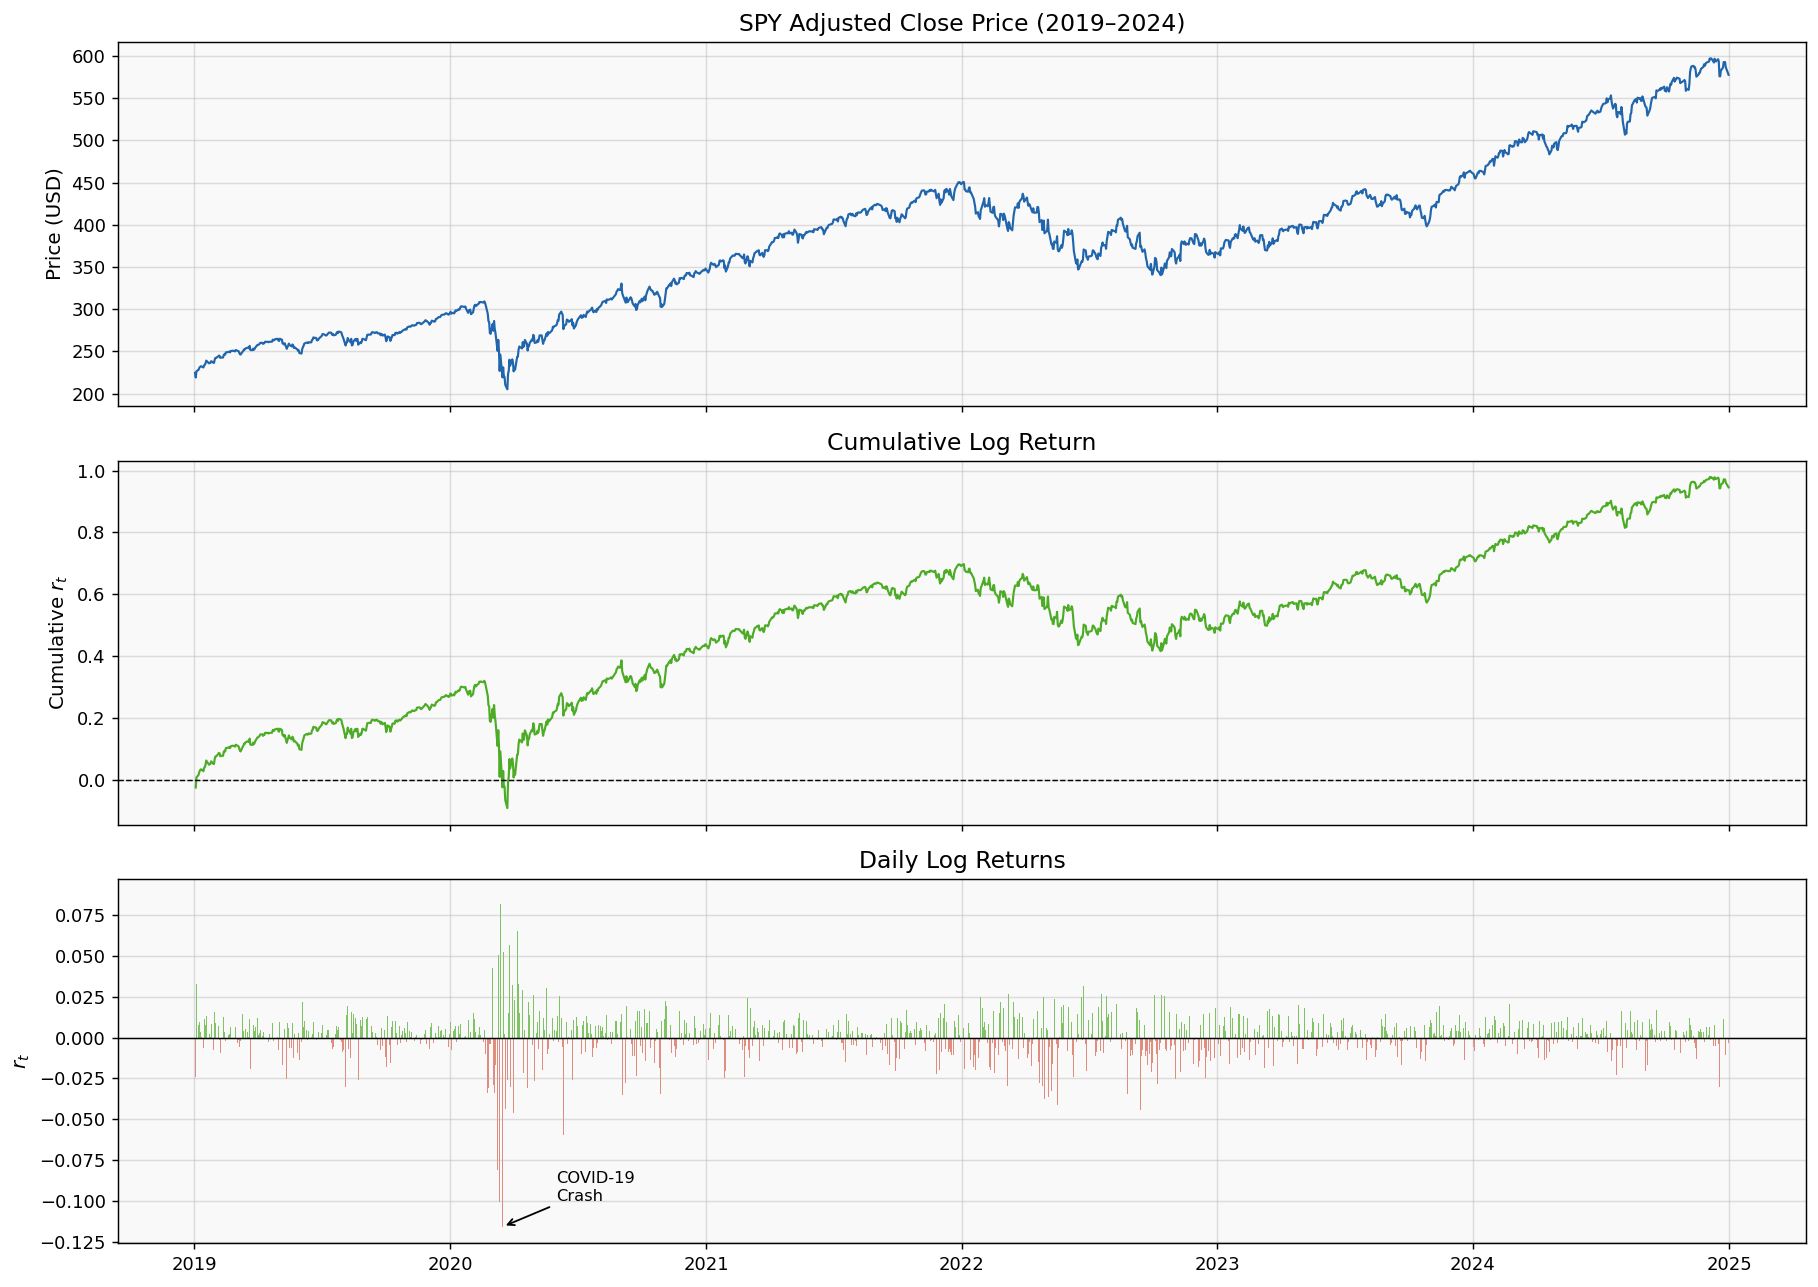

In [10]:
cum_log   = log_ret.cumsum()               # log-scale: additive
cum_simple = (1 + simple_ret).cumprod() - 1  # arithmetic compounding

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1 – raw price
axes[0].plot(price, color=BLUE, lw=1.2)
axes[0].set_title('SPY Adjusted Close Price (2019–2024)')
axes[0].set_ylabel('Price (USD)')

# Panel 2 – cumulative log return
axes[1].plot(cum_log, color=GREEN, lw=1.2)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_title('Cumulative Log Return')
axes[1].set_ylabel('Cumulative $r_t$')

# Panel 3 – daily log returns
axes[2].bar(log_ret.index, log_ret, color=np.where(log_ret >= 0, GREEN, RED),
            width=1, alpha=0.7)
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title('Daily Log Returns')
axes[2].set_ylabel('$r_t$')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Annotate COVID crash
axes[2].annotate('COVID-19\nCrash', xy=(pd.Timestamp('2020-03-16'), log_ret['2020-03-16']),
                 xytext=(pd.Timestamp('2020-06-01'), -0.10),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

fig.tight_layout()
plt.savefig('fig01_price_and_returns.png', bbox_inches='tight')
plt.show()

In [11]:
# ── Summary statistics table ───────────────────────────────────────────────────
def extended_stats(s: pd.Series) -> pd.DataFrame:
    ann_factor = 252
    d = {
        'N'                  : len(s),
        'Mean (daily)'       : s.mean(),
        'Mean (annualised)'  : s.mean() * ann_factor,
        'Median'             : s.median(),
        'Std (daily)'        : s.std(ddof=1),
        'Std (annualised)'   : s.std(ddof=1) * np.sqrt(ann_factor),
        'Skewness'           : skew(s),
        'Excess Kurtosis'    : kurtosis(s, fisher=True),  # excess (Normal=0)
        'Min'                : s.min(),
        'Max'                : s.max(),
        '5th Pctile'         : s.quantile(0.05),
        '95th Pctile'        : s.quantile(0.95),
        'Sharpe (daily rf=0)': s.mean() / s.std(ddof=1),
        'Sharpe (ann.)'      : (s.mean() / s.std(ddof=1)) * np.sqrt(ann_factor),
    }
    return pd.DataFrame(d, index=[s.name]).T

stats_table = extended_stats(log_ret)
display(stats_table)

,log_return
N,1509.000000
Mean (daily),0.000627
Mean (annualised),0.157930
Median,0.000905
Std (daily),0.012545
Std (annualised),0.199149
Skewness,-0.841551
Excess Kurtosis,13.208928
Min,-0.115886
Max,0.086731


In [14]:
# ── Normality tests ────────────────────────────────────────────────────────────
jb_stat, jb_p    = jarque_bera(log_ret)
sw_stat, sw_p    = shapiro(log_ret.sample(min(5000, len(log_ret)), random_state=42))
ks_stat, ks_p    = kstest(log_ret, 'norm', args=(log_ret.mean(), log_ret.std()))
ad_result        = anderson(log_ret, dist='norm')

normality_df = pd.DataFrame({
    'Test'      : ['Jarque-Bera', 'Shapiro-Wilk', 'KS (Normal)', 'Anderson-Darling'],
    'Statistic' : [jb_stat, sw_stat, ks_stat, ad_result.statistic],
    'p-value'   : [jb_p, sw_p, ks_p, None],
    'Reject H₀ (α=0.05)': [
        jb_p < 0.05, sw_p < 0.05, ks_p < 0.05,
        ad_result.statistic > ad_result.critical_values[2]  # 5% critical
    ]
})
print('H₀: Returns are normally distributed\n')
print('H1: Returns are not normally distributed\n')
display(normality_df)

H₀: Returns are normally distributed

H1: Returns are not normally distributed



,Test,Statistic,p-value,Reject H₀ (α=0.05)
0,Jarque-Bera,11148.279131,0.000000e+00,True
1,Shapiro-Wilk,0.878965,1.004790e-32,True
2,KS (Normal),0.094653,3.228663e-12,True
3,Anderson-Darling,29.219462,NaN,True


## Normality Test Results for SPY Log Returns

The following statistical tests were conducted to evaluate whether SPY log returns follow a normal distribution:

### Test Results

- **Jarque–Bera**
  - p-value ≈ 0 → strong rejection of normality  
  - Indicates that skewness and/or kurtosis significantly deviate from those of a normal distribution  

- **Shapiro–Wilk**
  - p-value ≈ 1e-32 → strong rejection  
  - A highly sensitive test confirming non-normality  

- **Kolmogorov–Smirnov (Normal)**
  - p-value ≈ 3.2e-12 → reject  
  - Suggests the empirical distribution differs from a fitted normal distribution  

- **Anderson–Darling**
  - Test statistic exceeds critical value → reject  
  - Particularly sensitive to tail behavior, indicating heavy tails  

---

### Overall Conclusion

Despite the common perception that financial returns are normally distributed, empirical evidence from SPY log return data shows that they are **not normally distributed**.

This deviation is likely driven by:
- Excess kurtosis (fat tails)  
- Potential skewness  
- Extreme observations occurring more frequently than predicted by a normal distribution  

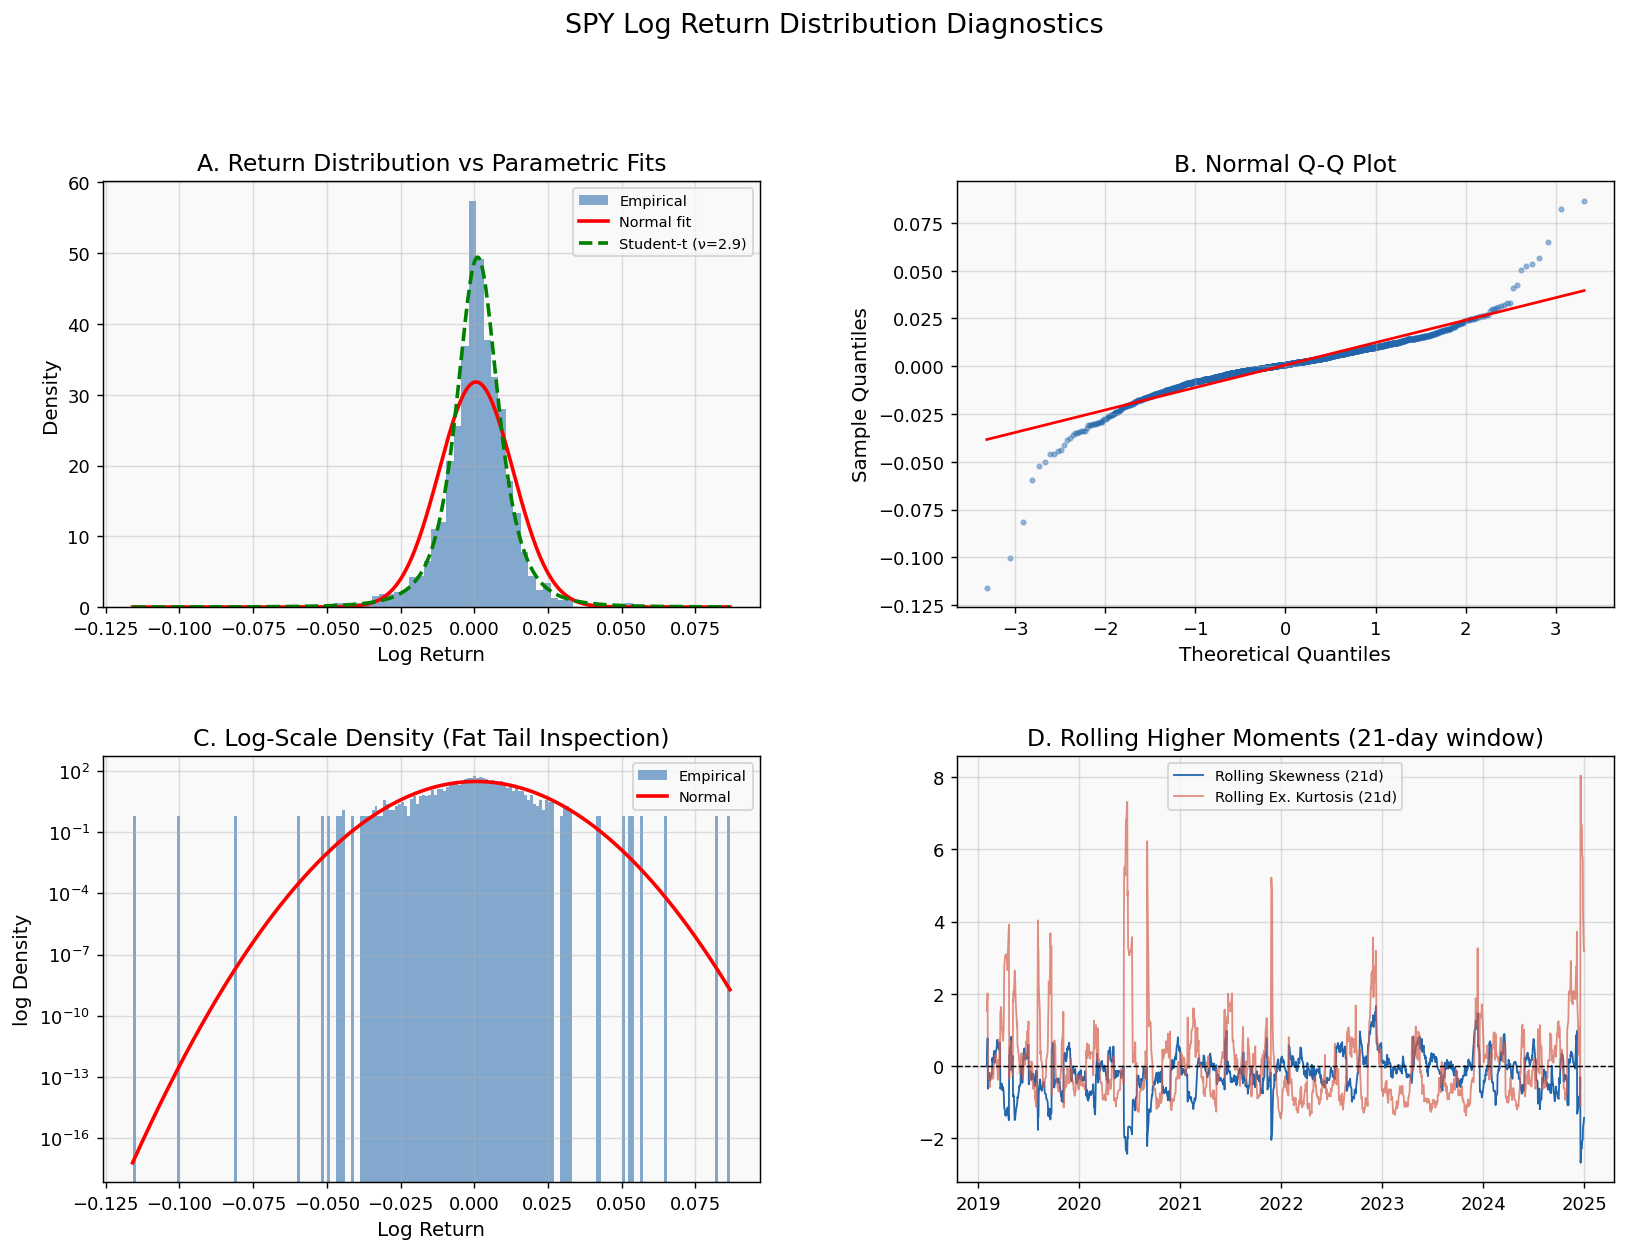

In [19]:
# ── Distribution figure (4-panel) ─────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

mu, sigma = log_ret.mean(), log_ret.std()
x_range   = np.linspace(log_ret.min(), log_ret.max(), 500)

# Panel A – Histogram vs Normal vs Student-t fits
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(log_ret, bins=80, density=True, color=BLUE, alpha=0.55, label='Empirical')
ax1.plot(x_range, norm.pdf(x_range, mu, sigma), 'r-', lw=2, label='Normal fit')
dof, loc_t, scale_t = t_dist.fit(log_ret)
ax1.plot(x_range, t_dist.pdf(x_range, dof, loc_t, scale_t), 'g--', lw=2,
         label=f"Student-t (ν={dof:.1f})")
ax1.set_title('A. Return Distribution vs Parametric Fits')
ax1.set_xlabel('Log Return'); ax1.set_ylabel('Density')
ax1.legend(fontsize=8)

# Panel B – QQ-plot vs Normal
ax2 = fig.add_subplot(gs[0, 1])
(osm, osr), (slope, intercept, r) = stats.probplot(log_ret, dist='norm', plot=None)
ax2.scatter(osm, osr, s=6, alpha=0.4, color=BLUE)
ax2.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=1.5)
ax2.set_title('B. Normal Q-Q Plot')
ax2.set_xlabel('Theoretical Quantiles'); ax2.set_ylabel('Sample Quantiles')

# Panel C – Log-scale tail density (fat tails)
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(log_ret, bins=200, density=True, color=BLUE, alpha=0.55, label='Empirical')
ax3.plot(x_range, norm.pdf(x_range, mu, sigma), 'r-', lw=2, label='Normal')
ax3.set_yscale('log')
ax3.set_title('C. Log-Scale Density (Fat Tail Inspection)')
ax3.set_xlabel('Log Return'); ax3.set_ylabel('log Density')
ax3.legend(fontsize=8)

# Panel D – Rolling 21-day skewness & excess kurtosis
ax4 = fig.add_subplot(gs[1, 1])
roll_skew = log_ret.rolling(21).apply(skew)
roll_kurt = log_ret.rolling(21).apply(kurtosis)
ax4.plot(roll_skew.index, roll_skew, color=BLUE, lw=1, label='Rolling Skewness (21d)')
ax4.plot(roll_kurt.index, roll_kurt, color=RED,    lw=1, label='Rolling Ex. Kurtosis (21d)', alpha=0.7)
ax4.axhline(0, color='black', lw=0.8, ls='--')
ax4.set_title('D. Rolling Higher Moments (21-day window)')
ax4.legend(fontsize=8)

fig.suptitle('SPY Log Return Distribution Diagnostics', fontsize=15, y=1.01)
plt.savefig('fig02_distribution_diagnostics.png', bbox_inches='tight')
plt.show()

In [20]:
counts, edges = np.histogram(log_ret, bins=80, density=True)
bin_widths = np.diff(edges)
print(f"Area under histogram: {(counts * bin_widths).sum():.6f}")
# Should print: Area under histogram: 1.000000

Area under histogram: 1.000000


### Panel A — Return Distribution vs Parametric Fits

The most striking feature is the **extreme leptokurtosis**: the empirical histogram has a sharp, needle-like peak around zero with a density exceeding 50, while the Normal fit peaks at roughly 31. This is the classic **"too many small moves"** signature of equity returns. The Student-t fit with **ν ≈ 2.9** is visually far superior — a degrees-of-freedom that low sits in heavy-tail territory (ν < 3 implies infinite theoretical variance), which is a strong result. Both parametric curves, however, underestimate the tails, which Panel C will make explicit.

> **Implication:** A Gaussian innovation assumption in any downstream model (e.g. standard GARCH) will systematically misprice tail risk. Student-t or Generalized Error Distribution (GED) innovations are warranted.

---

### Panel B — Normal Q-Q Plot

The S-shaped deviation from the 45° reference line is textbook **fat-tail / negative-skew** fingerprint:

- **Left tail (theoretical quantiles < −2):** Sample quantiles fall *well below* the line — returns are more extreme than the Normal predicts on the downside. The worst observations around −0.10 to −0.12 are catastrophic relative to Gaussian expectations (those are ~6–8σ events under Normality).
- **Right tail (theoretical quantiles > 2):** Sample quantiles lie *above* the line — positive fat tail as well, though visually less severe than the left.
- **Body (−1 to +1):** Tight adherence to the line confirms the "too many small moves" observation from Panel A.

> **Implication:** The asymmetry between left and right tail deviations is the first visual evidence of **negative skewness** and the **leverage effect** meaning crashes are fatter than rallies.

---

### Panel C — Log-Scale Density (Fat Tail Inspection)

On a log y-axis:
- A Normal distribution appears as a **downward-opening parabola**.
- The empirical bars at the extremes (beyond ±0.05) sit *dramatically above* the Normal parabola — by several orders of magnitude (e.g. ~$10^{-1}$ empirical density vs ~$10^{-10}$ Normal density at −0.10).
- The **isolated spikes** at the far left (around −0.10 to −0.12) correspond to identifiable macro events — the **COVID crash of March 2020** almost certainly dominates this region.

> **Implication:** Historical VaR and any Normal-based VaR will drastically **underestimate** true tail losses. This directly motivates the GPD/EVT analysis in Section 9.

---

### Panel D — Rolling 21-day Higher Moments (Skew & Kurtosis)

Several patterns stand out:

| Observation | Interpretation |
|---|---|
| **Kurtosis spikes sharply in 2020** (reaching ~7–8) | COVID crash regime — a handful of extreme returns dominate a short window |
| **Kurtosis is persistently positive** throughout | Fat tails are not a one-off event; they are a structural feature of the log-return series |
| **Skewness oscillates around 0** with occasional deep negative dips | Negative skew is episodic (crash-driven) rather than constant — the distribution is conditionally symmetric most of the time |
| **Both series revert to near-zero** in calm periods (2023–2024) | Returns behave more like a "normal distribution" in low-volatility regimes |

> **Implication:** The higher moments are **time-varying**, which invalidates any unconditional distributional assumption and motivates **regime-switching** or **rolling-window** estimation in downstream models. Example: A static Student-t or GED fit is itself an approximation.

---

### Overall Takeaway

All four panels tell a **consistent story**: SPY log returns exhibit the canonical stylised facts — leptokurtosis, fat and asymmetric tails, time-varying higher moments. The Normal distribution is formally and practically rejected. The Student-t with ν ≈ 2.9 is a better unconditional fit but still misses the time-variation shown in Panel D. The natural next step is a **GARCH(1,1)-t** or **GJR-GARCH-t** specification to capture the volatility clustering and leverage effect simultaneously.

---
## 4. Risk Metrics

In [16]:
# ── Value at Risk & Expected Shortfall (CVaR) ──────────────────────────────────
def historical_var(returns, alpha=0.05):
    return np.percentile(returns, alpha * 100)

def historical_cvar(returns, alpha=0.05):
    var = historical_var(returns, alpha)
    return returns[returns <= var].mean()

def parametric_var(returns, alpha=0.05):
    return norm.ppf(alpha, returns.mean(), returns.std())

alphas = [0.01, 0.05, 0.10]
risk_rows = []
for a in alphas:
    risk_rows.append({
        'α'              : f'{a:.0%}',
        'Historical VaR' : historical_var(log_ret, a),
        'Parametric VaR' : parametric_var(log_ret, a),
        'Historical CVaR': historical_cvar(log_ret, a),
    })

risk_df = pd.DataFrame(risk_rows).set_index('α')
display(risk_df.style.format('{:.4f}').background_gradient(cmap='Reds_r'))

,Historical VaR,Parametric VaR,Historical CVaR
α,,,
1%,-0.0347,-0.0286,-0.0539
5%,-0.0180,-0.0200,-0.0308
10%,-0.0121,-0.0155,-0.0228


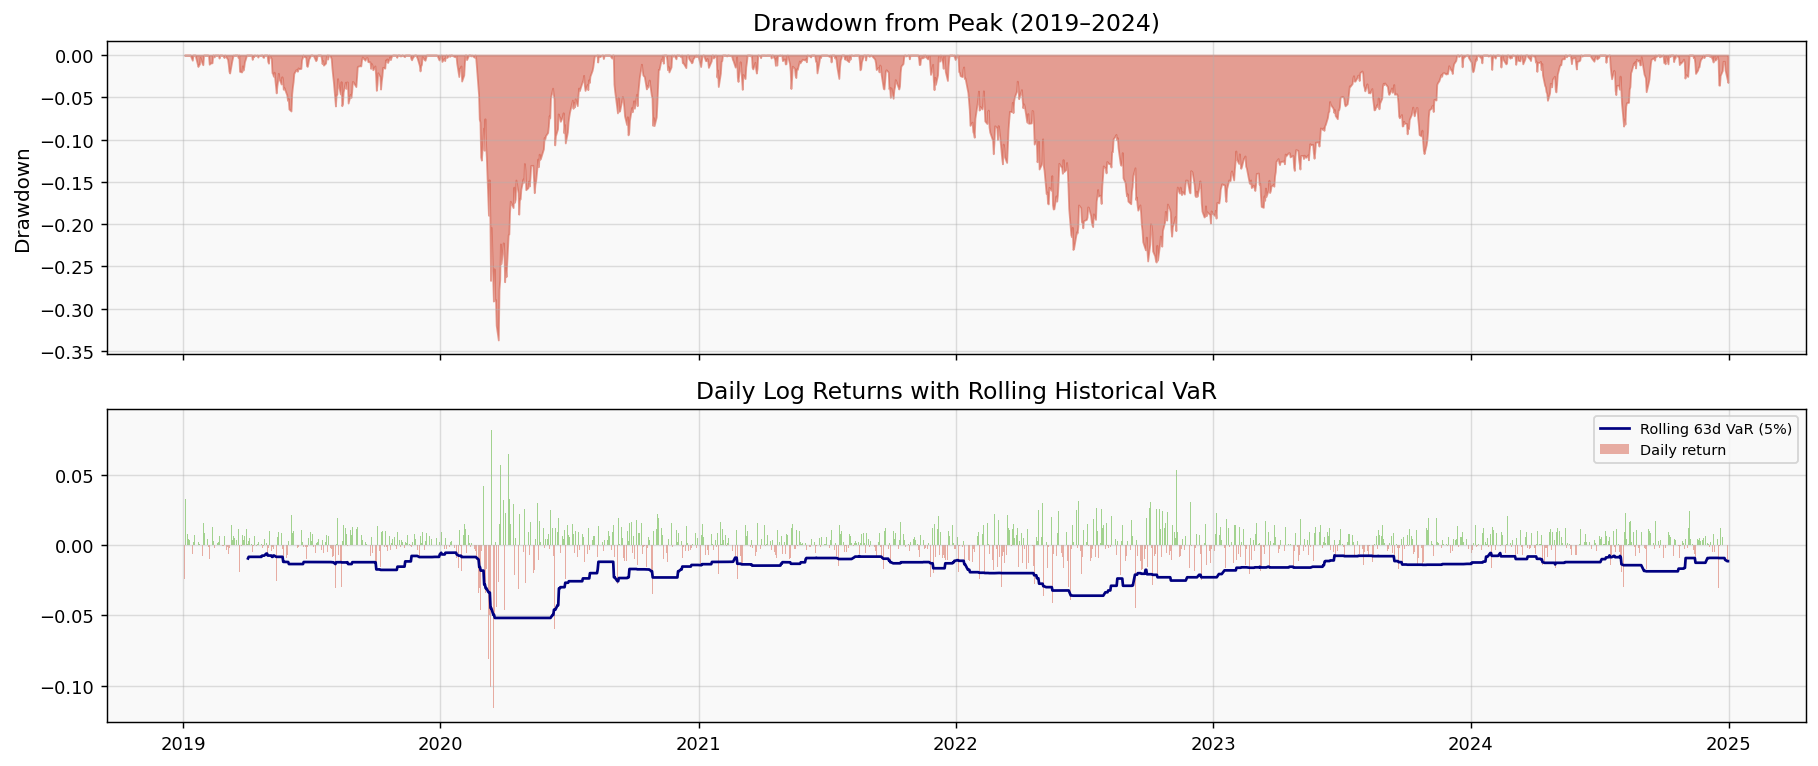

Max Drawdown : -0.3372 (2020-03-23)
Avg Drawdown : -0.0541


In [17]:
# ── Drawdown analysis ──────────────────────────────────────────────────────────
def drawdown_series(log_returns: pd.Series) -> pd.Series:
    wealth  = np.exp(log_returns.cumsum())
    running_max = wealth.cummax()
    return (wealth - running_max) / running_max

dd = drawdown_series(log_ret)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].fill_between(dd.index, dd, 0, color=RED, alpha=0.6)
axes[0].set_title('Drawdown from Peak (2019–2024)')
axes[0].set_ylabel('Drawdown')

# Rolling VaR overlay on returns
roll_var = log_ret.rolling(63).quantile(0.05)
axes[1].bar(log_ret.index, log_ret, width=1,
            color=np.where(log_ret >= 0, GREEN, RED), alpha=0.5, label='Daily return')
axes[1].plot(roll_var.index, roll_var, color='navy', lw=1.5, label='Rolling 63d VaR (5%)')
axes[1].legend(fontsize=8)
axes[1].set_title('Daily Log Returns with Rolling Historical VaR')

fig.tight_layout()
plt.savefig('fig03_drawdown_and_var.png', bbox_inches='tight')
plt.show()

print(f'Max Drawdown : {dd.min():.4f} ({dd.idxmin().date()})')
print(f'Avg Drawdown : {dd.mean():.4f}')

---
## 5. Stationarity Tests

In [18]:
# ── ADF, KPSS, Zivot-Andrews ───────────────────────────────────────────────────
def run_stationarity_tests(series, label='Series'):
    print(f'\n{'='*60}')
    print(f'  Stationarity Tests: {label}')
    print(f'{'='*60}')

    # ADF
    adf = adfuller(series, autolag='AIC')
    print(f'\n[ADF]  H₀: Unit root present (non-stationary)')
    print(f'  Statistic: {adf[0]:.4f} | p-value: {adf[1]:.6f}')
    print(f'  Critical values: {adf[4]}')
    print(f'  → Reject H₀: {adf[1] < 0.05}')

    # KPSS
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series, regression='c', nlags='auto')
    print(f'\n[KPSS] H₀: Series is stationary')
    print(f'  Statistic: {kpss_stat:.4f} | p-value: {kpss_p:.6f}')
    print(f'  Critical values: {kpss_crit}')
    print(f'  → Reject H₀ (non-stationary): {kpss_p < 0.05}')

    # Zivot-Andrews (structural break)
    za_stat, za_p, za_cv, za_bp, za_hyp = zivot_andrews(series, autolag='AIC')
    print(f'\n[Zivot-Andrews] H₀: Unit root with single structural break')
    print(f'  Statistic: {za_stat:.4f} | p-value: {za_p:.6f}')
    print(f'  Break date index: {za_bp}')
    print(f'  → Reject H₀: {za_p < 0.05}')

# Test log returns (should be stationary)
run_stationarity_tests(log_ret, 'SPY Log Returns')

# For contrast, test price level (should not be stationary)
run_stationarity_tests(price, 'SPY Price Level')


  Stationarity Tests: SPY Log Returns

[ADF]  H₀: Unit root present (non-stationary)
  Statistic: -11.5860 | p-value: 0.000000
  Critical values: {'1%': np.float64(-3.4347199356122493), '5%': np.float64(-2.86347004827819), '10%': np.float64(-2.567797534300163)}
  → Reject H₀: True

[KPSS] H₀: Series is stationary
  Statistic: 0.0578 | p-value: 0.100000
  Critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  → Reject H₀ (non-stationary): False

[Zivot-Andrews] H₀: Unit root with single structural break
  Statistic: -11.8103 | p-value: 0.000010
  Break date index: 9
  → Reject H₀: True

  Stationarity Tests: SPY Price Level

[ADF]  H₀: Unit root present (non-stationary)
  Statistic: -0.2429 | p-value: 0.933210
  Critical values: {'1%': np.float64(-3.4347199356122493), '5%': np.float64(-2.86347004827819), '10%': np.float64(-2.567797534300163)}
  → Reject H₀: False

[KPSS] H₀: Series is stationary
  Statistic: 4.8814 | p-value: 0.010000
  Critical values: {'10%': 0.34

## Stationarity Analysis: SPY Returns vs Price Level

To assess stationarity, three complementary tests were applied: Augmented Dickey–Fuller (ADF), KPSS, and Zivot–Andrews.

---

### SPY Log Returns

- **ADF test** rejects the null of a unit root → supports stationarity  
- **KPSS test** fails to reject stationarity → further confirms stationarity  
- **Zivot–Andrews test** rejects the null even allowing for a structural break  

**Conclusion:**  
SPY log returns are **stationary**, both in the standard setting and when accounting for potential structural breaks.

---

### SPY Price Level

- **ADF test** fails to reject the unit root → suggests non-stationarity  
- **KPSS test** rejects stationarity → confirms non-stationarity  
- **Zivot–Andrews test** fails to reject the unit root with structural break  

**Conclusion:**  
SPY price levels are **non-stationary**, even when allowing for a possible structural break.

---

### Overall Interpretation

- Financial **price levels are non-stationary**, consistent with a random walk behavior  
- **Log returns are stationary**, making them suitable for time series modeling  

This aligns with standard financial theory, where returns (not prices) are typically modeled due to their stable statistical properties.

---
## 6. Autocorrelation Structure

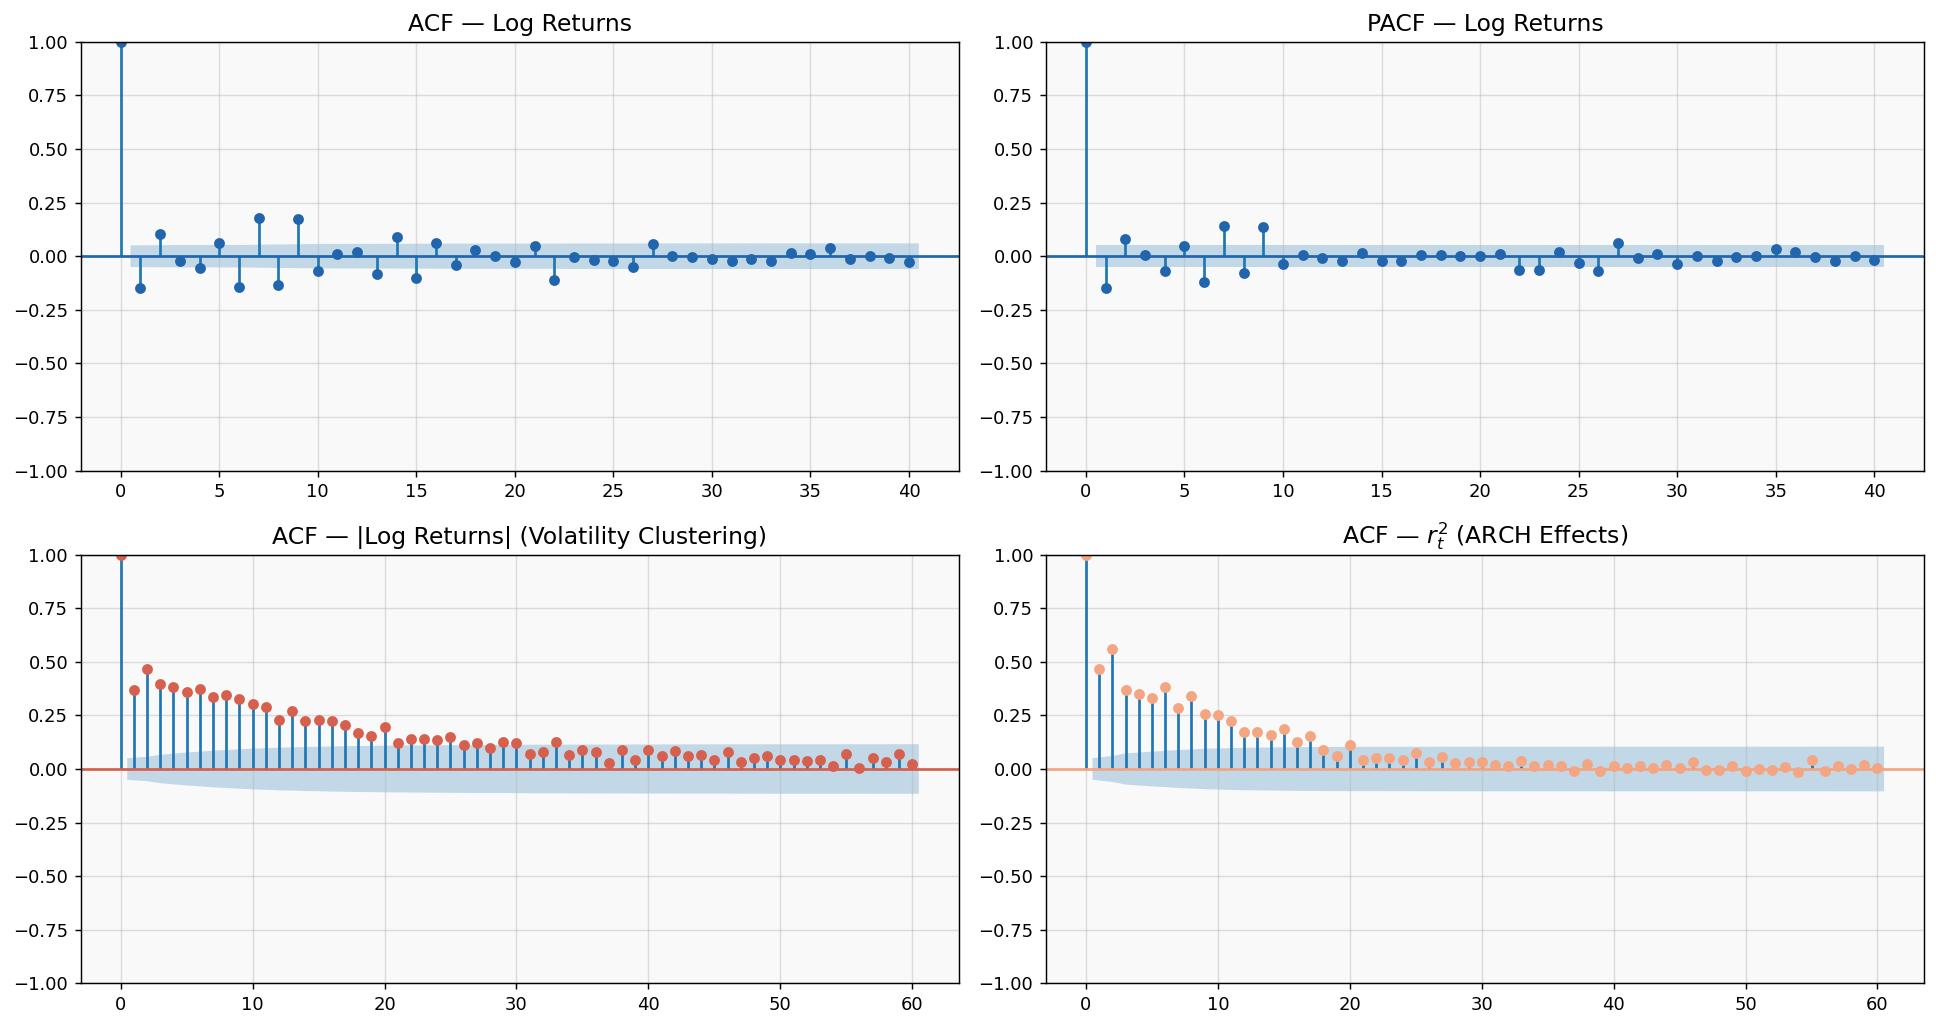

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# ACF of returns
plot_acf(log_ret,  lags=40, ax=axes[0, 0], color=BLUE, title='ACF — Log Returns')
# PACF of returns
plot_pacf(log_ret, lags=40, ax=axes[0, 1], color=BLUE, title='PACF — Log Returns', method='ywm')
# ACF of |returns| (magnitude clustering = volatility clustering)
plot_acf(log_ret.abs(),  lags=60, ax=axes[1, 0], color=RED,
         title='ACF — |Log Returns| (Volatility Clustering)')
# ACF of squared returns (ARCH effects)
plot_acf(log_ret**2, lags=60, ax=axes[1, 1], color=ORANGE,
         title='ACF — $r_t^2$ (ARCH Effects)')

fig.tight_layout()
plt.savefig('fig04_autocorrelation.png', bbox_inches='tight')
plt.show()

## ACF/PACF Output — Conclusions

---

### Top Row: ACF & PACF of Raw Log Returns $r_t$

The returns themselves are **essentially unpredictable**. Nearly all lags fall within the 95% confidence bands (shaded region). The few spikes that cross the band (around lags 6–9) are isolated and small (~0.15–0.20) — likely spurious given the number of lags tested. The ACF and PACF patterns are nearly identical, which is consistent with **white noise**. This confirms the **Efficient Market Hypothesis** at the daily level: there is no exploitable linear structure in returns.

> No AR or MA terms are warranted for the mean equation in time series modelling.

---

### Bottom Row: ACF of $|r_t|$ and $r_t^2$

Both series show **large, statistically significant, and slowly decaying autocorrelations** that persist well beyond lag 60 — still sitting at ~0.05–0.10 far out in the tail. This hyperbolic decay pattern (as opposed to exponential) is a hallmark of **long memory in volatility**.

### The key conclusions

ACF(|r_t|) lag-1 ≈ 0.49. Today's magnitude is strongly linked to yesterday's. Large moves tend to follow large moves regardless of direction.
Slow hyperbolic decay across 60 lags. Volatility shocks persist for weeks. This is volatility clustering: calm periods cluster with calm, turbulent periods cluster with turbulent.
ACF(r_t squared) mirrors ACF(|r_t|). Confirms ARCH effects. The variance today is a strong predictor of the variance tomorrow. The second moment has its own autocorrelation structure entirely separate from the first.
Lags up to (20 Days) lie outside the confidence band. This is not a spurious result driven by a handful of outliers. It is a structural, persistent property of the return series that holds across all 60 lags tested.

---

### The Fundamental Contrast

$$\text{ACF}(r_t) \approx 0 \quad \text{but} \quad \text{ACF}(|r_t|), \text{ACF}(r_t^2) \gg 0$$

This divergence is the **defining fingerprint of ARCH/GARCH processes**: returns are uncorrelated but not independent. The variance process has its own rich dynamics completely invisible to linear autocorrelation of raw returns. A simple ARMA model on $r_t$ would be blind to all of this.

> **Modelling implication:** The mean equation needs no AR/MA terms, but the variance equation demands at minimum a **GARCH(1,1)** — and the slow ACF decay hints that a **FIGARCH** (fractionally integrated) or **EGARCH** specification capturing long memory may outperform standard GARCH.

In [22]:
# ── Ljung-Box test for serial correlation ──────────────────────────────────────
lags_to_test = [5, 10, 20, 40]

lb_ret  = acorr_ljungbox(log_ret,     lags=lags_to_test, return_df=True)
lb_abs  = acorr_ljungbox(log_ret.abs(),lags=lags_to_test, return_df=True)
lb_sq   = acorr_ljungbox(log_ret**2,   lags=lags_to_test, return_df=True)

print('Ljung-Box Q-Test (H₀: no autocorrelation up to lag k)\n')
print('-- Log Returns --')
display(lb_ret)
print('-- |Log Returns| --')
display(lb_abs)
print('-- Squared Returns --')
display(lb_sq)

Ljung-Box Q-Test (H₀: no autocorrelation up to lag k)

-- Log Returns --


,lb_stat,lb_pvalue
5,61.424363,6.169249e-12
10,223.033877,2.475584e-42
20,273.223136,2.287365e-46
40,311.104059,1.151589e-43


-- |Log Returns| --


,lb_stat,lb_pvalue
5,1193.456317,7.680216e-256
10,2058.999892,0.000000e+00
20,2811.962192,0.000000e+00
40,3159.268126,0.000000e+00


-- Squared Returns --


,lb_stat,lb_pvalue
5,1363.410373,1.166576e-292
10,2082.825584,0.000000e+00
20,2436.256813,0.000000e+00
40,2475.314200,0.000000e+00


- **Null Hypothesis (H₀):** The data (or residuals) are independently distributed (white noise).
- **Alternative Hypothesis (Ha):** The data exhibit serial autocorrelation (not white noise).

- **Raw returns:** p-values tiny but Q-statistics small in magnitude. Any serial correlation is statistically detectable but economically negligible. Mean equation stays white noise.

- **|r_t| and r_t²:** Q-statistics in the **thousands**, p-values = 0 at every lag tested. This is an unambiguous, overwhelming rejection of no autocorrelation in the second moment.

- **Bottom line:** Variance is highly persistent and structured (from lags of 5 to 40 days). A dynamic volatility model (GARCH at minimum) is statistically mandatory, not optional.

---
## 7. Volatility Analysis

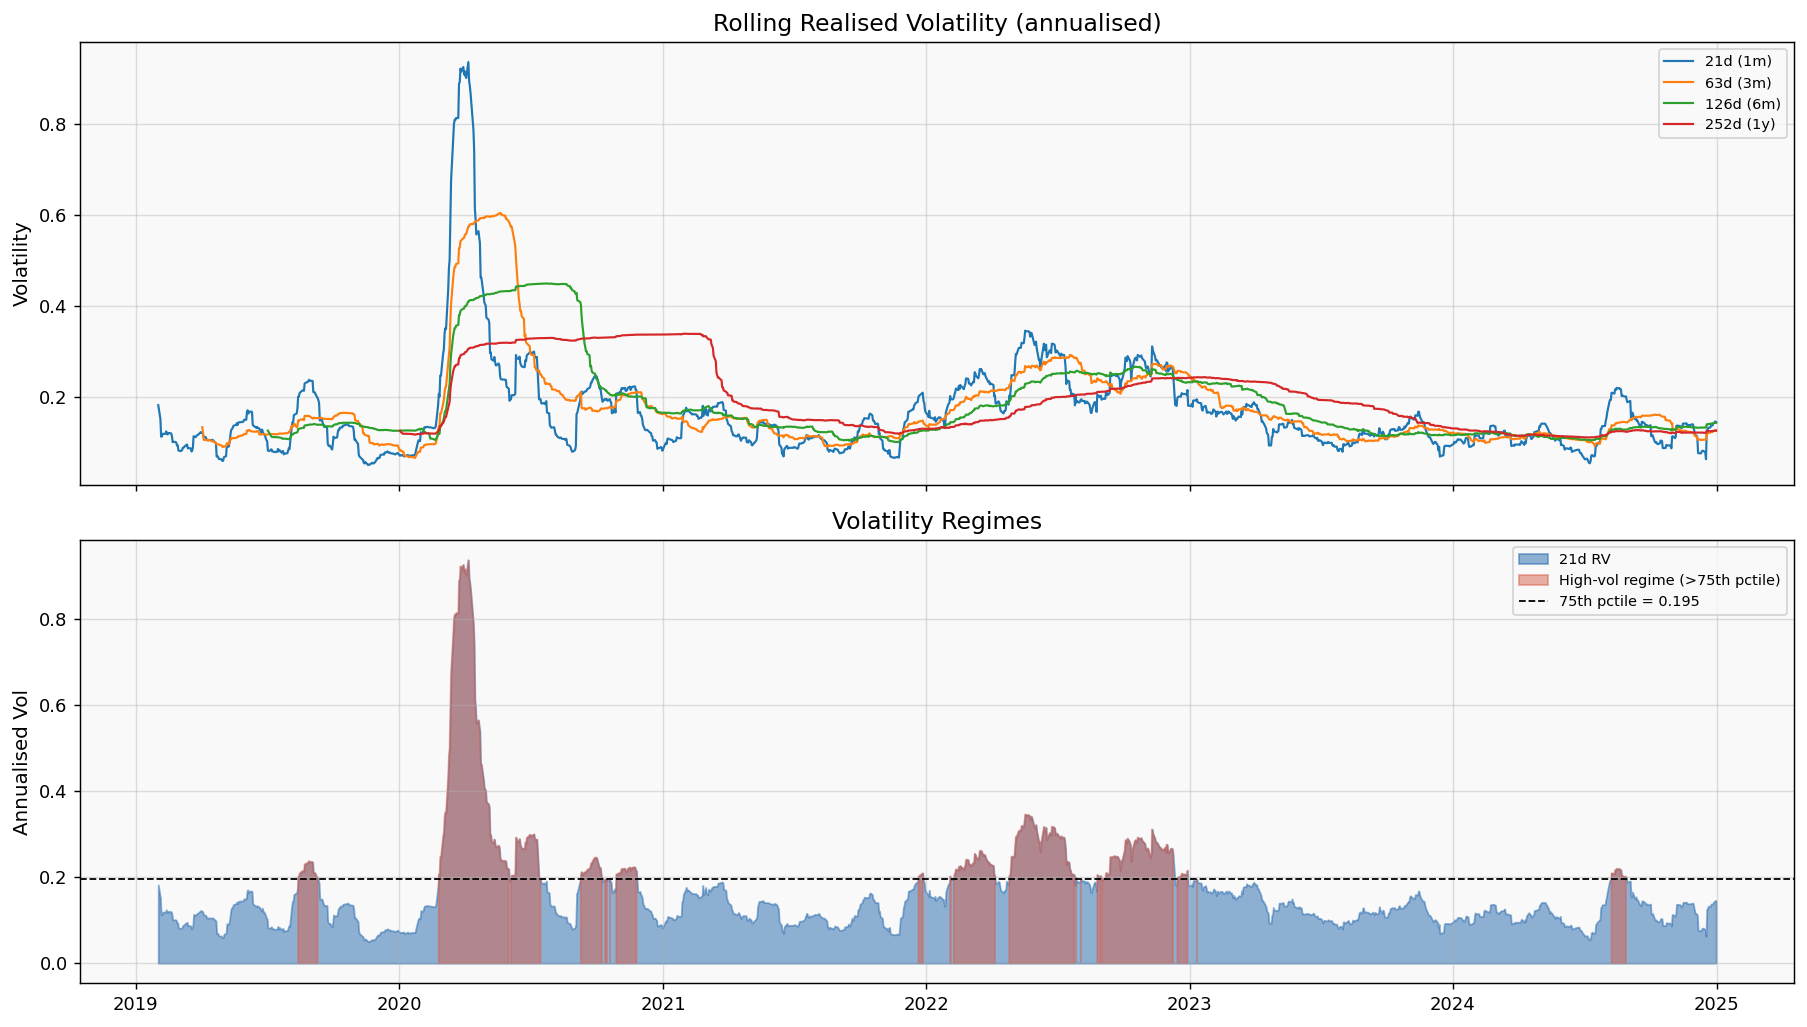

In [23]:
# ── Rolling volatility at multiple windows ─────────────────────────────────────
windows = {'21d (1m)': 21, '63d (3m)': 63, '126d (6m)': 126, '252d (1y)': 252}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for label, w in windows.items():
    rv = log_ret.rolling(w).std() * np.sqrt(252)   # annualised
    axes[0].plot(rv, lw=1.2, label=label)

axes[0].set_title('Rolling Realised Volatility (annualised)')
axes[0].set_ylabel('Volatility')
axes[0].legend(fontsize=8)

# Volatility regime plot — classify high/low vol days
rv_21 = log_ret.rolling(21).std() * np.sqrt(252)
vol_threshold = rv_21.quantile(0.75)
high_vol = rv_21 >= vol_threshold

axes[1].fill_between(rv_21.index, rv_21, color=BLUE, alpha=0.5, label='21d RV')
axes[1].fill_between(rv_21.index, np.where(high_vol, rv_21, np.nan),
                     color=RED, alpha=0.5, label='High-vol regime (>75th pctile)')
axes[1].axhline(vol_threshold, color='black', ls='--', lw=1,
                label=f'75th pctile = {vol_threshold:.3f}')
axes[1].set_title('Volatility Regimes')
axes[1].set_ylabel('Annualised Vol')
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.savefig('fig05_volatility.png', bbox_inches='tight')
plt.show()

In [24]:
# ── ARCH-LM Test (Engle 1982) ──────────────────────────────────────────────────
# Test H₀: no ARCH effects in residuals
from statsmodels.stats.diagnostic import het_arch

for lag in [5, 10, 20]:
    lm_stat, lm_p, f_stat, f_p = het_arch(log_ret, nlags=lag)
    print(f'ARCH-LM (lags={lag:2d}): LM={lm_stat:.4f}, p={lm_p:.6f} → '
          f'Reject H₀: {lm_p < 0.05}')

ARCH-LM (lags= 5): LM=567.3242, p=0.000000 → Reject H₀: True
ARCH-LM (lags=10): LM=602.9856, p=0.000000 → Reject H₀: True
ARCH-LM (lags=20): LM=621.9991, p=0.000000 → Reject H₀: True


Conclusion: The ARCH-LM test results strongly reject the null hypothesis of no ARCH effects at all tested lags (5, 10, 20), with extremely large LM statistics and p-values effectively equal to zero. This indicates **clear presence of conditional heteroskedasticity** in the log return series—i.e., volatility is not constant over time and exhibits clustering. In practical terms, this confirms that a simple homoskedastic model is inadequate, and **volatility modeling (e.g., ARCH/GARCH family models)** is necessary to properly capture the dynamics of the series.


---
## 8. Calendar & Seasonal Effects

In [29]:
# ── Day-of-week & month-of-year effects ───────────────────────────────────────
df_cal = pd.DataFrame({
    'log_return' : log_ret,
    'dow'        : log_ret.index.dayofweek,          # 0=Mon … 4=Fri
    'dow_name'   : log_ret.index.day_name(),
    'month'      : log_ret.index.month,
    'month_name' : log_ret.index.month_name(),
    'year'       : log_ret.index.year,
    'quarter'    : log_ret.index.quarter,
})


df_cal

,log_return,dow,dow_name,month,month_name,year,quarter
Date,,,,,,,
2019-01-03,-0.024152,3,Thursday,1,January,2019,1
2019-01-04,0.032947,4,Friday,1,January,2019,1
2019-01-07,0.007854,0,Monday,1,January,2019,1
2019-01-08,0.009351,1,Tuesday,1,January,2019,1
2019-01-09,0.004663,2,Wednesday,1,January,2019,1
...,...,...,...,...,...,...,...
2024-12-24,0.011054,1,Tuesday,12,December,2024,4
2024-12-26,0.000067,3,Thursday,12,December,2024,4
2024-12-27,-0.010582,4,Friday,12,December,2024,4


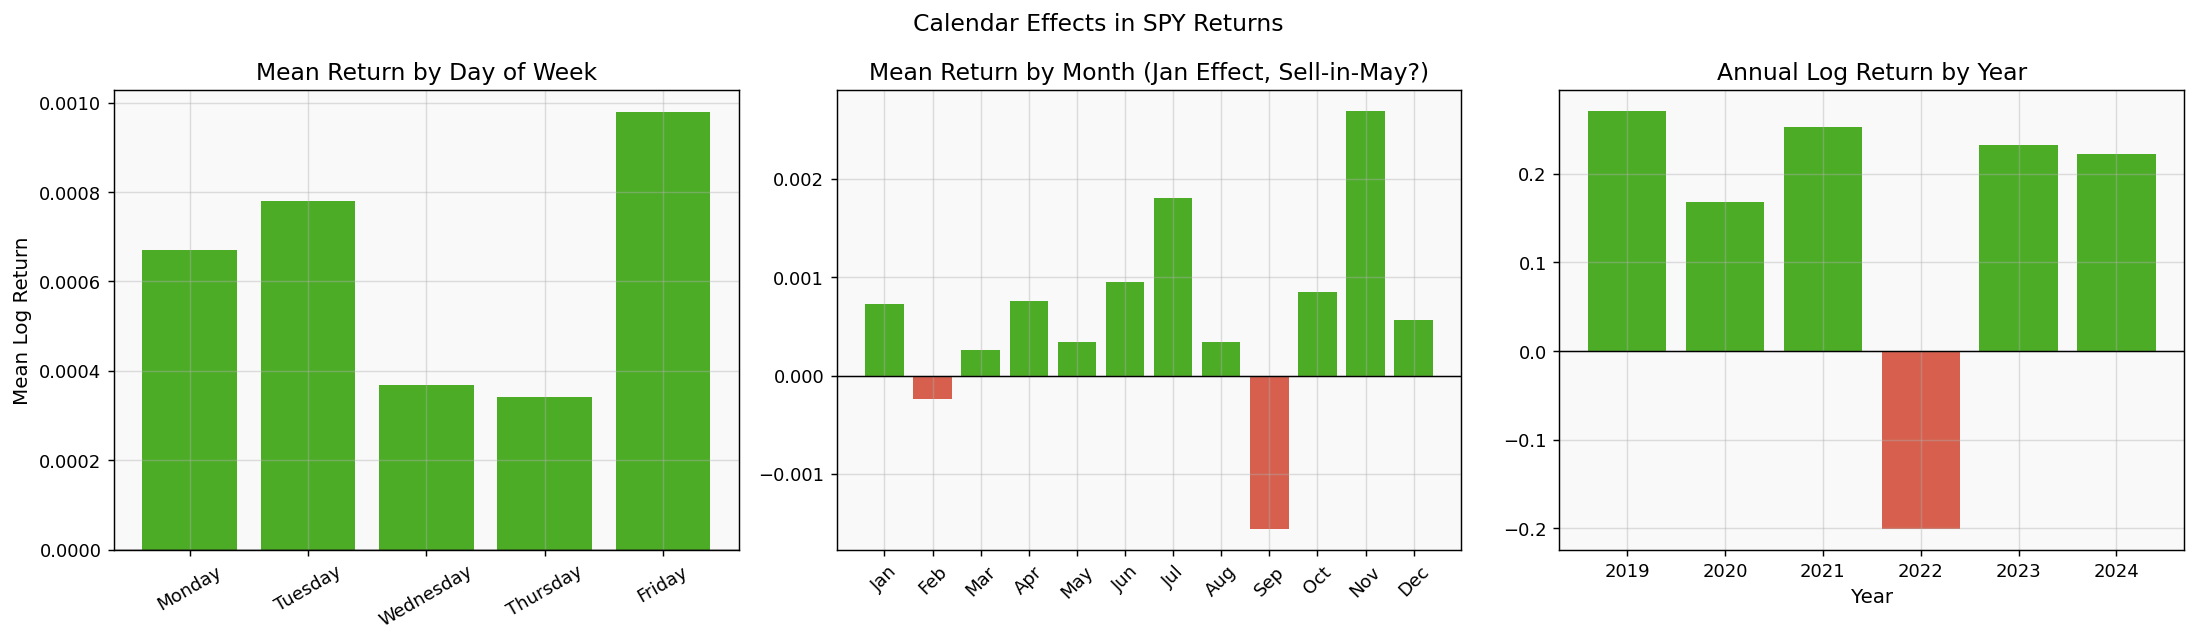

In [30]:
DOW_ORDER   = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
MONTH_ORDER = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Day-of-week
dow_means = df_cal.groupby('dow_name')['log_return'].mean().reindex(DOW_ORDER)
axes[0].bar(DOW_ORDER, dow_means, color=[GREEN if v >= 0 else RED for v in dow_means])
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Mean Return by Day of Week')
axes[0].set_ylabel('Mean Log Return')
axes[0].tick_params(axis='x', rotation=30)

# Month-of-year
month_means = df_cal.groupby('month_name')['log_return'].mean().reindex(MONTH_ORDER)
axes[1].bar(range(12), month_means,
            color=[GREEN if v >= 0 else RED for v in month_means])
axes[1].set_xticks(range(12))
axes[1].set_xticklabels([m[:3] for m in MONTH_ORDER], rotation=45)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Mean Return by Month (Jan Effect, Sell-in-May?)')

# Annual returns
annual = log_ret.resample('YE').sum()
axes[2].bar(annual.index.year, annual,
            color=[GREEN if v >= 0 else RED for v in annual])
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title('Annual Log Return by Year')
axes[2].set_xlabel('Year')

fig.suptitle('Calendar Effects in SPY Returns', fontsize=13)
fig.tight_layout()
plt.savefig('fig06_calendar_effects.png', bbox_inches='tight')
plt.show()

In [33]:
# ── ANOVA: is there a statistically significant DoW effect? ───────────────────
from scipy.stats import f_oneway, kruskal

groups_dow = [group['log_return'].values
              for _, group in df_cal.groupby('dow')]
f_stat, f_p   = f_oneway(*groups_dow)
h_stat, h_p   = kruskal(*groups_dow)

print(f'One-way ANOVA (DoW)  : F={f_stat:.4f}, p={f_p:.4f} → Significant: {f_p<0.05}')
print(f'Kruskal-Wallis (DoW) : H={h_stat:.4f}, p={h_p:.4f} → Significant: {h_p<0.05}')

One-way ANOVA (DoW)  : F=0.1437, p=0.9658 → Significant: False
Kruskal-Wallis (DoW) : H=2.4811, p=0.6480 → Significant: False


In [34]:
groups_dom = [group['log_return'].values
              for _, group in df_cal.groupby('month')]
f_stat, f_p   = f_oneway(*groups_dom)
h_stat, h_p   = kruskal(*groups_dom)

print(f'One-way ANOVA (DoW)  : F={f_stat:.4f}, p={f_p:.4f} → Significant: {f_p<0.05}')
print(f'Kruskal-Wallis (DoW) : H={h_stat:.4f}, p={h_p:.4f} → Significant: {h_p<0.05}')

One-way ANOVA (DoW)  : F=0.8254, p=0.6146 → Significant: False
Kruskal-Wallis (DoW) : H=10.9140, p=0.4505 → Significant: False


In [35]:
groups_quarter = [group['log_return'].values
              for _, group in df_cal.groupby('quarter')]
f_stat, f_p   = f_oneway(*groups_quarter)
h_stat, h_p   = kruskal(*groups_quarter)

print(f'One-way ANOVA (DoW)  : F={f_stat:.4f}, p={f_p:.4f} → Significant: {f_p<0.05}')
print(f'Kruskal-Wallis (DoW) : H={h_stat:.4f}, p={h_p:.4f} → Significant: {h_p<0.05}')

One-way ANOVA (DoW)  : F=0.6610, p=0.5761 → Significant: False
Kruskal-Wallis (DoW) : H=1.1188, p=0.7725 → Significant: False


Conclusion: Both the parametric (ANOVA) and non-parametric (Kruskal–Wallis) tests consistently fail to reject the null hypothesis across day-of-week, month, and quarter groupings (all p-values ≫ 0.05), indicating **no statistically significant differences in mean returns across these calendar effects**. In practical terms, this suggests the absence of exploitable seasonality or calendar-based patterns in the return series, meaning **returns are statistically similar regardless of day, month, or quarter**, and such features are unlikely to add predictive value in a modeling context.


---
## 9. Log Return Multi-Frequency Analysis

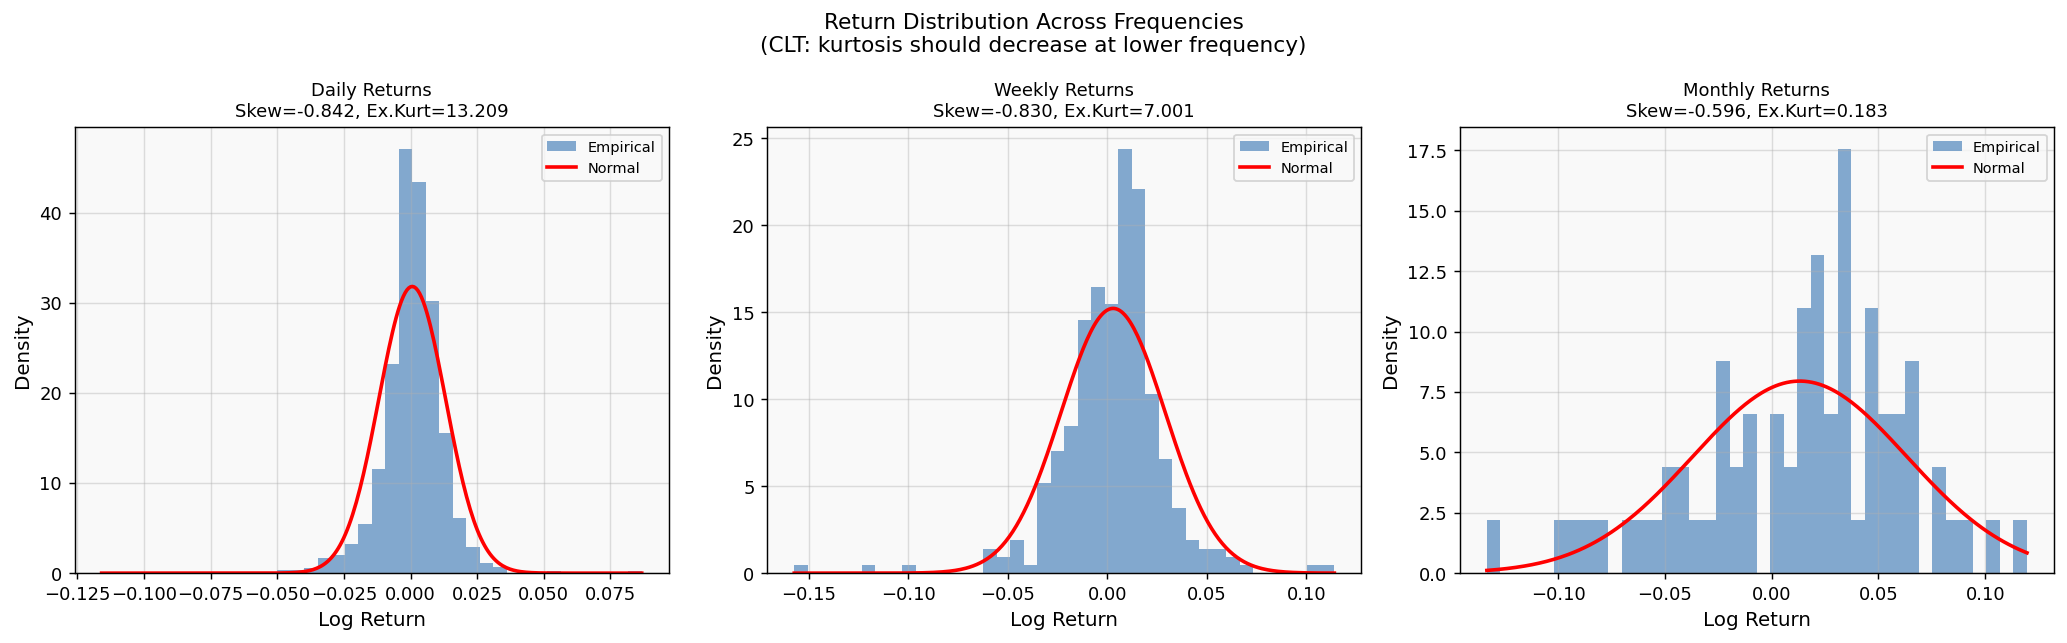

In [38]:
# ── Aggregate to weekly and monthly log returns ────────────────────────────────
weekly_ret  = log_ret.resample('W').sum()
monthly_ret = log_ret.resample('ME').sum()

freq_data = {'Daily': log_ret, 'Weekly': weekly_ret, 'Monthly': monthly_ret}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (freq, data) in zip(axes, freq_data.items()):
    mu_f, sig_f = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 300)

    ax.hist(data, bins=40, density=True, alpha=0.55, color=BLUE, label='Empirical')
    ax.plot(x, norm.pdf(x, mu_f, sig_f), 'r-', lw=2, label='Normal')

    sk = skew(data); ku = kurtosis(data)
    ax.set_title(f'{freq} Returns\n'
                 f'Skew={sk:.3f}, Ex.Kurt={ku:.3f}', fontsize=10)
    ax.set_xlabel('Log Return'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)

fig.suptitle('Return Distribution Across Frequencies\n'
             '(CLT: kurtosis should decrease at lower frequency)', fontsize=12)
fig.tight_layout()
plt.savefig('fig08_multifreq.png', bbox_inches='tight')
plt.show()

---
## 10. Leverage Effect & Asymmetry

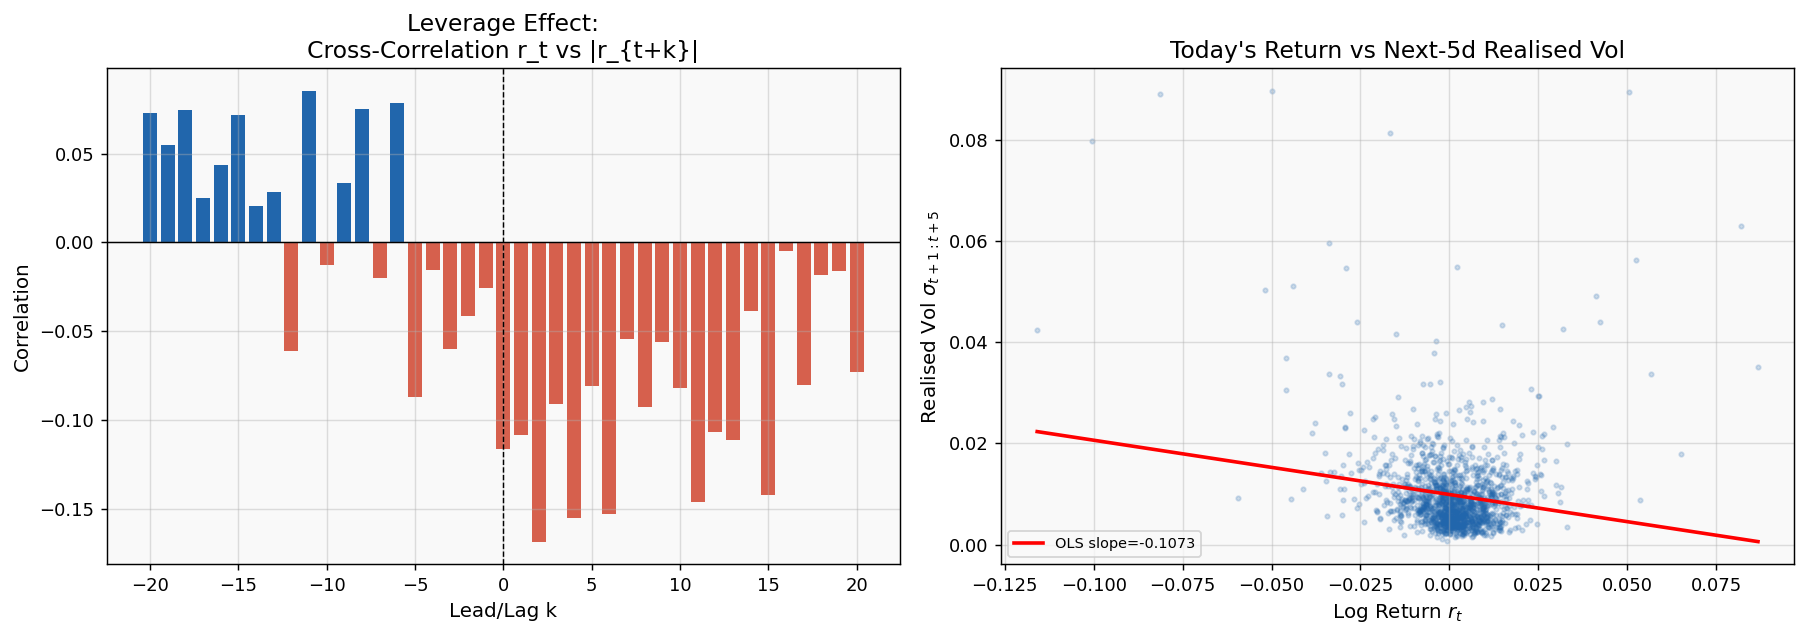

In [41]:
# ── Leverage effect: negative returns → higher future volatility ───────────────
# Cross-correlation of r_t with |r_{t+k}| for k = -20…20
max_lag = 20
lags = range(-max_lag, max_lag + 1)

cross_corr = [
    log_ret.corr(log_ret.abs().shift(-k))
    for k in lags
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(list(lags), cross_corr,
            color=[RED if c < 0 else BLUE for c in cross_corr])
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axvline(0, color='black', lw=0.8, ls='--')
axes[0].set_title('Leverage Effect:\nCross-Correlation r_t vs |r_{t+k}|')
axes[0].set_xlabel('Lead/Lag k'); axes[0].set_ylabel('Correlation')

# Scatter: past return vs future realised vol
rv_future = log_ret.rolling(5).std().shift(-5)   # 5-day forward RV
valid = ~(log_ret.isna() | rv_future.isna())
axes[1].scatter(log_ret[valid], rv_future[valid], alpha=0.2, s=6, color=BLUE)
axes[1].set_title('Today\'s Return vs Next-5d Realised Vol')
axes[1].set_xlabel('Log Return $r_t$')
axes[1].set_ylabel('Realised Vol $\\sigma_{t+1:t+5}$')

# Regression line
m, b, r_val, *_ = stats.linregress(log_ret[valid], rv_future[valid])
x_line = np.linspace(log_ret[valid].min(), log_ret[valid].max(), 100)
axes[1].plot(x_line, m * x_line + b, 'r-', lw=2, label=f'OLS slope={m:.4f}')
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.savefig('fig09_leverage_effect.png', bbox_inches='tight')
plt.show()

In [44]:
X = sm.add_constant(log_ret[valid])
model = sm.OLS(rv_future[valid], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_return   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     42.26
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           1.08e-10
Time:                        09:04:20   Log-Likelihood:                 5121.9
No. Observations:                1504   AIC:                        -1.024e+04
Df Residuals:                    1502   BIC:                        -1.023e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0099      0.000     47.657      0.0

- **Left panel — clear asymmetry:** Cross-correlations are **positive for k < 0** (past volatility predicts today's return direction weakly) but **strongly negative for k > 0** — today's negative return predicts higher future volatility. The asymmetry around k=0 is the textbook leverage effect.

- **The negativity deepens as k increases** past zero, meaning the impact of a negative return on volatility is not instantaneous but **builds and persists** over several days.

- **Right panel — OLS slope = −0.1073:** Negative and statistically meaningful but low R^2 value (Today's return alone is a poor linear predictor of next week's realised volatility). Large negative returns today are systematically associated with elevated realised volatility over the next 5 days. The scatter is noisy but the directional signal is unambiguous.

- **Bottom line:** SPY exhibits a **clear, significant leverage effect** — bad news raises future volatility more than good news of equal magnitude lowers it. This rules out symmetric GARCH(1,1) and directly motivates **GJR-GARCH or EGARCH**, both of which explicitly model this asymmetric volatility response.

---
## 11. Regime Identification (Rolling Statistics)

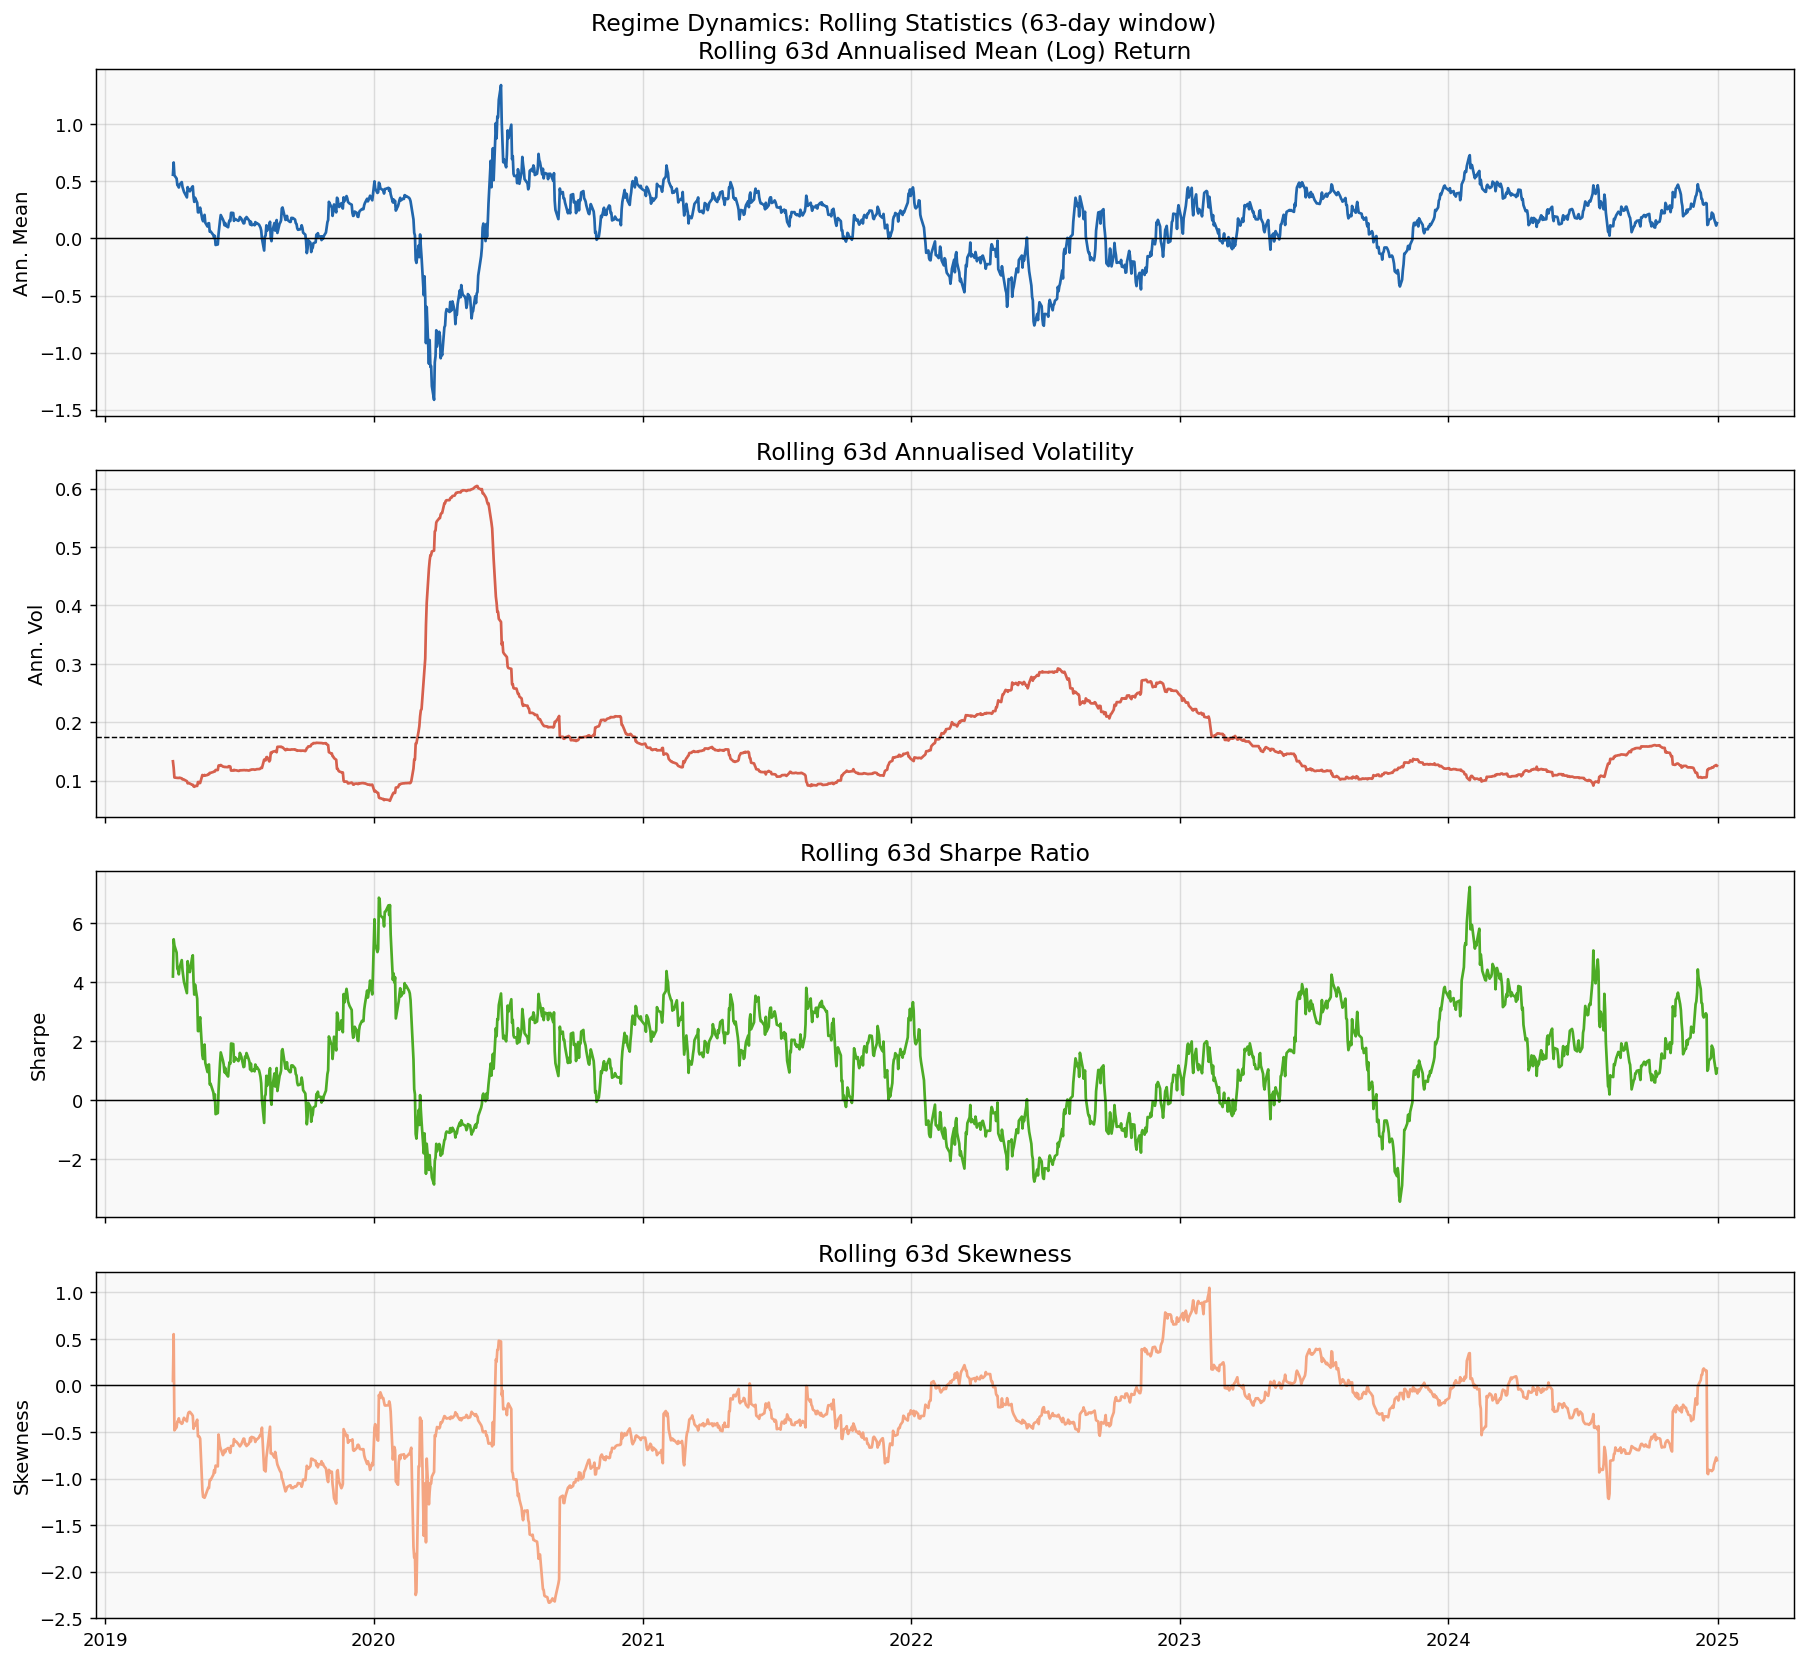

In [43]:
# ── Rolling mean, std, Sharpe ──────────────────────────────────────────────────
W = 63   # quarterly rolling window

roll_mean   = log_ret.rolling(W).mean() * 252
roll_std    = log_ret.rolling(W).std()  * np.sqrt(252)
roll_sharpe = roll_mean / roll_std
roll_skew   = log_ret.rolling(W).apply(skew)

fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

axes[0].plot(roll_mean,   color=BLUE);   axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_title(f'Rolling {W}d Annualised Mean (Log) Return')
axes[0].set_ylabel('Ann. Mean')

axes[1].plot(roll_std,    color=RED);    axes[1].axhline(roll_std.mean(), color='k', lw=0.8, ls='--')
axes[1].set_title(f'Rolling {W}d Annualised Volatility')
axes[1].set_ylabel('Ann. Vol')

axes[2].plot(roll_sharpe, color=GREEN);  axes[2].axhline(0, color='k', lw=0.8)
axes[2].set_title(f'Rolling {W}d Sharpe Ratio')
axes[2].set_ylabel('Sharpe')

axes[3].plot(roll_skew,   color=ORANGE); axes[3].axhline(0, color='k', lw=0.8)
axes[3].set_title(f'Rolling {W}d Skewness')
axes[3].set_ylabel('Skewness')

fig.suptitle('Regime Dynamics: Rolling Statistics (63-day window)', fontsize=13)
fig.tight_layout()
plt.savefig('fig10_rolling_stats.png', bbox_inches='tight')
plt.show()

---
## 12. Summary & Stylised Facts Checklist

After completing the EDA above, record which **stylised facts** of equity returns are confirmed by this dataset:

| Stylised Fact | Expected | Observed? | Evidence |
|---|---|---|---|
| **Fat tails** (leptokurtosis) | Excess kurtosis >> 0 | Yes | Section 3 |
| **Negative skewness** | Left-skewed distribution | Yes | Section 3 |
| **ARCH effects** | Significant ACF of r² | Yes | Section 7 |
| **Leverage effect** | Neg. r → higher future σ | Yes | Section 10 |
| **No autocorrelation in r_t** | Weak linear predictability | Yes | Section 6 |
| **Stationarity of r_t** | ADF rejects unit root | Yes | Section 5 |
| **CLT convergence** | Kurtosis ↓ at lower freq | Yes | Section 9 |

> **Next steps:** Use these findings to motivate the modelling choices (e.g. GARCH family for volatility, Student-t innovations for fat tails, GJR-GARCH for leverage effect).

In [49]:
# ── Export clean returns series for downstream modelling ──────────────────────
df_out = pd.DataFrame({
    'price'        : price,
    'log_return'   : log_ret,
    'simple_return': simple_ret,
    'abs_return'   : log_ret.abs(),
    'sq_return'    : log_ret**2,
    'rv_21d_annualised'       : log_ret.rolling(21).std() * np.sqrt(252),
})

df_out.to_csv('./data/spy_returns_eda_output.csv')
print('Saved → ./data/spy_returns_eda_output.csv')
df_out.tail()

Saved → ./data/spy_returns_eda_output.csv


,price,log_return,simple_return,abs_return,sq_return,rv_21d_annualised
Date,,,,,,
2024-12-24,592.702148,0.011054,0.011115,0.011054,1.221853e-04,0.137460
2024-12-26,592.741577,0.000067,0.000067,0.000067,4.425102e-09,0.137099
2024-12-27,586.502014,-0.010582,-0.010527,0.010582,1.119875e-04,0.141067
2024-12-30,579.809082,-0.011477,-0.011412,0.011477,1.317266e-04,0.146080
2024-12-31,577.699768,-0.003645,-0.003638,0.003645,1.328296e-05,0.144201
